# PGA-UNet — Ablation Study
**Checkpoint**: `1Mv-rUPI7KGmYemd27hmKbJQRHc4ZKB9z`

Chứng minh **thành phần nào** khiến PGA vượt SAM-Med2D fine-tuned.

| Test | Câu hỏi | Mục báo cáo |
|------|---------|-------------|
| **T1** | Hard bbox vs Gaussian heatmap | `tab:ablation_prompt` |
| **T1b** | Null/Random/Hard/Gaussian/Oracle | `tab:ablation_prompt` |
| **T1c** | Tight/Zoom/Shift robustness | `tab:ablation_robustness` |
| **T2** | Small/Medium/Large lesions | `tab:subcategory` |

**Chạy tuần tự**: Setup → Helpers → T1 → T1b → T1c → T2

In [1]:
# ── Setup ─────────────────────────────────────────────────────────
%cd /kaggle/working
import os, gdown

if not os.path.exists('Prompt-Guided-XRay-Segmentation'):
    !git clone -b TN_B_ON https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git
else:
    !cd Prompt-Guided-XRay-Segmentation && git pull -q

!gdown 1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3 -O /kaggle/working/dataset_BTXRD.zip -q
!unzip -oq /kaggle/working/dataset_BTXRD.zip -d /kaggle/working/
!rsync -a /kaggle/working/dataset_BTXRD/ /kaggle/working/Prompt-Guided-XRay-Segmentation/dataset_BTXRD/ 2>/dev/null

%cd /kaggle/working/Prompt-Guided-XRay-Segmentation
!pip install -q tqdm opencv-python matplotlib gdown scipy

CKPT_ID   = '1Mv-rUPI7KGmYemd27hmKbJQRHc4ZKB9z'
CKPT_PATH = 'checkpoints/pga_unet_expB_best.pth'
os.makedirs('checkpoints', exist_ok=True)
if not os.path.exists(CKPT_PATH):
    gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)
print(f'\n✅ Setup xong  |  {os.path.getsize(CKPT_PATH)//1024} KB')

/kaggle/working
Cloning into 'Prompt-Guided-XRay-Segmentation'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 186 (delta 64), reused 88 (delta 35), pack-reused 62 (from 1)
Receiving objects: 100% (186/186), 36.63 MiB | 24.34 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/kaggle/working/Prompt-Guided-XRay-Segmentation


Downloading...
From: https://drive.google.com/uc?id=1Mv-rUPI7KGmYemd27hmKbJQRHc4ZKB9z
To: /kaggle/working/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_expB_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 58.2MB/s]


✅ Setup xong  |  11615 KB


In [2]:
# ── Helpers dùng chung cho tất cả tests ──────────────────────────
import os, cv2, json, csv, glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt
from models.networks.prompt_unet_2D import PGA_UNet

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 512
IMG_DIR  = 'dataset_BTXRD/test/images'
JSON_DIR = 'dataset_BTXRD/test/annotations'
os.makedirs('results/ablation', exist_ok=True)

model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f'\u2705 Model loaded  device={DEVICE}')

def extract_lcc(m):
    if m.sum()==0: return m
    n,lbl,st,_=cv2.connectedComponentsWithStats(m.astype(np.uint8),8)
    return m if n<=1 else (lbl==(1+np.argmax(st[1:,cv2.CC_STAT_AREA]))).astype(np.float32)

def calc_hd95(pred,gt):
    p,g=pred.astype(bool),gt.astype(bool)
    if not p.any() and not g.any(): return 0.0
    if not p.any() or not g.any(): return float(IMG_SIZE)
    pe=p^binary_erosion(p); ge=g^binary_erosion(g)
    d1=distance_transform_edt(~ge)[pe]; d2=distance_transform_edt(~pe)[ge]
    return float(IMG_SIZE) if not len(d1) or not len(d2) else float(max(np.percentile(d1,95),np.percentile(d2,95)))

def calc_metrics(prob_np, gt_np):
    pm=extract_lcc((prob_np>0.5).astype(np.float32))
    gm=(gt_np>0.5).astype(np.float32); eps=1e-6
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    hd95=calc_hd95(pm,gm)
    if gm.sum()==0 or pm.sum()==0: cbl=0.0
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/(np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps),0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)),iou=float((tp+eps)/(tp+fp+fn+eps)),
                precision=float((tp+eps)/(tp+fp+eps)),recall=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95,cbl=cbl,mask=pm)

def run_forward(img_np, pm_np, gt_np):
    img_t=torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    pm_t =torch.from_numpy(pm_np).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        prob=torch.sigmoid(model(img_t,pm_t))[0,0].cpu().numpy()
    return calc_metrics(prob,gt_np)

def print_table(title, rows, N):
    KEYS=['dice','iou','precision','recall','hd95','cbl']
    HDRS=['Dice\u2191','IoU\u2191','Prec\u2191','Rec\u2191','HD95\u2193','CBL\u2191']
    bar='\u2550'*78
    print(f'\n{bar}\n  {title}  |  N={N}\n{bar}')
    print(f"  {'Model':<34}"+''.join(f'{h:>8}' for h in HDRS))
    print(f"  {'\u2500'*74}")
    for label,m in rows:
        print(f"  {label:<34}"+''.join(f"{m[k]:>8.2f}" if k=='hd95' else f"{m[k]:>8.4f}" for k in KEYS))
    print(bar)

def save_csv(path, rows, header):
    with open(path,'w',newline='') as f:
        w=csv.writer(f); w.writerow(header); w.writerows(rows)
    print(f'  \u2192 CSV: {path}')

# ── Load test samples từ JSON ─────────────────────────────────
def load_test_samples(json_dir, img_dir, zoom_r=0.30):
    samples=[]
    for jf in sorted(glob.glob(f'{json_dir}/*.json')):
        base=os.path.splitext(os.path.basename(jf))[0]
        img_path=next((f'{img_dir}/{base}{e}' for e in ['.png','.jpg','.jpeg']
                       if os.path.exists(f'{img_dir}/{base}{e}')),None)
        if not img_path: continue
        img_bgr=cv2.imread(img_path); H0,W0=img_bgr.shape[:2]
        data=json.load(open(jf))
        for shape in [s for s in data.get('shapes',[]) if s.get('shape_type')=='polygon']:
            pts=np.array(shape['points'],dtype=np.float32)
            x1r,x2r=pts[:,0].min(),pts[:,0].max(); y1r,y2r=pts[:,1].min(),pts[:,1].max()
            img_rs=cv2.resize(img_bgr,(IMG_SIZE,IMG_SIZE))
            sx,sy=IMG_SIZE/W0,IMG_SIZE/H0
            x1,x2,y1,y2=x1r*sx,x2r*sx,y1r*sy,y2r*sy
            pts_rs=pts.copy(); pts_rs[:,0]*=sx; pts_rs[:,1]*=sy
            gt=np.zeros((IMG_SIZE,IMG_SIZE),dtype=np.uint8)
            cv2.fillPoly(gt,[pts_rs.astype(np.int32).reshape(-1,1,2)],255)
            gt=(gt/255).astype(np.float32)
            img_gray=cv2.cvtColor(img_rs.astype(np.float32)/255.,cv2.COLOR_BGR2GRAY)
            img_norm=(img_gray-0.5)/0.5
            bw,bh=x2-x1,y2-y1
            bx1=max(0,x1-bw*zoom_r); bx2=min(IMG_SIZE,x2+bw*zoom_r)
            by1=max(0,y1-bh*zoom_r); by2=min(IMG_SIZE,y2+bh*zoom_r)
            samples.append(dict(img_np=img_norm,gt_np=gt,
                                bbox_zoom=[bx1,by1,bx2,by2],gt_area=int(gt.sum())))
    print(f'\u2705 {len(samples)} samples')
    return samples

def make_gaussian_heatmap(bbox, size=512):
    x1,y1,x2,y2=[max(0,min(size,v)) for v in bbox]
    hm=np.zeros((size,size),dtype=np.float32)
    hm[int(y1):int(y2),int(x1):int(x2)]=1.0
    sigma=max(1,int((x2-x1+y2-y1)/8))
    hm=cv2.GaussianBlur(hm,(0,0),sigmaX=sigma,sigmaY=sigma)
    mx=hm.max(); return hm/mx if mx>0 else hm

def make_hard_bbox(bbox, size=512):
    x1,y1,x2,y2=[max(0,min(size,v)) for v in bbox]
    hm=np.zeros((size,size),dtype=np.float32)
    hm[int(y1):int(y2),int(x1):int(x2)]=1.0; return hm

TEST_SAMPLES = load_test_samples(JSON_DIR, IMG_DIR, zoom_r=0.30)
KEYS=['dice','iou','precision','recall','hd95','cbl']
print(f'   N={len(TEST_SAMPLES)} polygon samples')

✅ Model loaded  device=cuda
✅ 248 samples
   N=248 polygon samples


---
## T1 — Hard Bbox vs Gaussian Heatmap
**→ `tab:ablation_prompt`**

Cùng model, cùng zoom_out 30%, khác nhau DUY NHẤT ở prompt encoding.

| PGA hard bbox > SAM-FT | U-Net architecture tốt hơn SAM, heatmap cộng thêm |
| PGA hard bbox ≈ SAM-FT | **Gaussian heatmap là "khúc" quyết định** |

In [10]:
records_gaussian=[]; records_hard=[]
for s in tqdm(TEST_SAMPLES,'T1'):
    records_gaussian.append(run_forward(s['img_np'],make_gaussian_heatmap(s['bbox_zoom']),s['gt_np']))
    records_hard.append(run_forward(s['img_np'],make_hard_bbox(s['bbox_zoom']),s['gt_np']))

m_g={k:np.mean([r[k] for r in records_gaussian]) for k in KEYS}
m_h={k:np.mean([r[k] for r in records_hard]) for k in KEYS}
m_sam=dict(dice=0.7624,iou=0.6424,precision=0.7597,recall=0.7880,hd95=52.08,cbl=0.9003)
m_unet=dict(dice=0.5090,iou=0.4125,precision=0.6686,recall=0.5235,hd95=125.12,cbl=0.6457)
rows=[('U-Net (no prompt)*',m_unet),('SAM-Med2D FT (hard bbox)',m_sam),
      ('PGA + Hard binary bbox',m_h),('PGA + Gaussian heatmap ✓',m_g)]
print_table('T1 — HARD BBOX vs GAUSSIAN HEATMAP  (zoom_out 30%)',rows,len(TEST_SAMPLES))
print('  * U-Net N=187; PGA/SAM N=248')
print(f'\n  \u0394 Gaussian vs Hard : {m_g["dice"]-m_h["dice"]:+.4f} Dice')
print(f'  \u0394 PGA hard vs SAM  : {m_h["dice"]-m_sam["dice"]:+.4f} Dice')
save_csv('results/ablation/t1_hard_vs_gaussian.csv',
    [['U-Net']+[f'{m_unet[k]:.4f}' for k in KEYS]+['187'],
     ['SAM-FT']+[f'{m_sam[k]:.4f}' for k in KEYS]+['248'],
     ['PGA Hard']+[f'{m_h[k]:.4f}' for k in KEYS]+[str(len(TEST_SAMPLES))],
     ['PGA Gaussian']+[f'{m_g[k]:.4f}' for k in KEYS]+[str(len(TEST_SAMPLES))]],
    ['model']+KEYS+['N'])

T1: 100%|██████████| 248/248 [00:30<00:00,  8.16it/s]


══════════════════════════════════════════════════════════════════════════════
  T1 — HARD BBOX vs GAUSSIAN HEATMAP  (zoom_out 30%)  |  N=248
══════════════════════════════════════════════════════════════════════════════
  Model                                Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑
  ──────────────────────────────────────────────────────────────────────────
  U-Net (no prompt)*                  0.5090  0.4125  0.6686  0.5235  125.12  0.6457
  SAM-Med2D FT (hard bbox)            0.7624  0.6424  0.7597  0.7880   52.08  0.9003
  PGA + Hard binary bbox              0.8593  0.7604  0.8827  0.8543   12.14  0.9572
  PGA + Gaussian heatmap ✓            0.8298  0.7184  0.9162  0.7763   14.25  0.9524
══════════════════════════════════════════════════════════════════════════════
  * U-Net N=187; PGA/SAM N=248

  Δ Gaussian vs Hard : -0.0295 Dice
  Δ PGA hard vs SAM  : +0.0969 Dice
  → CSV: results/ablation/t1_hard_vs_gaussian.csv


---
## T1b — Ablation Đầy Đủ: 5 Loại Prompt
**→ `tab:ablation_prompt`**

| Prompt | Câu hỏi |
|---|---|
| **Null (zeros)** | PGA architecture thuần có tốt hơn U-Net/Att-UNet? |
| **Random noise** | PSG có filter nhiễu không? |
| **Hard bbox** | Thêm vị trí cứng giúp bao nhiêu? |
| **Gaussian** | Soft encoding thêm bao nhiêu? |
| **GT oracle** | Ceiling — tiềm năng còn lại? |

T1b: 100%|██████████| 248/248 [00:23<00:00, 10.57it/s]



══════════════════════════════════════════════════════════════════════════════
  T1b — 5 LOẠI PROMPT  (zoom_out 30%)  |  N=248
══════════════════════════════════════════════════════════════════════════════
  Model                                Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑
  ──────────────────────────────────────────────────────────────────────────
  ① U-Net (no prompt)*                0.5090  0.4125  0.6686  0.5235  125.12  0.6457
  ② Att-UNet (no prompt)*             0.4110  0.3212  0.6261  0.4035  141.23  0.5917
  ③ PGA + Null (zeros)                0.0005  0.0002  1.0000  0.0002  501.51  0.0214
  ④ PGA + Random noise                0.0015  0.0008  0.9758  0.0008  495.84  0.0208
  ⑤ SAM-Med2D FT (hard bbox)          0.7624  0.6424  0.7597  0.7880   52.08  0.9003
  ⑥ PGA + Hard bbox                   0.8593  0.7604  0.8827  0.8543   12.14  0.9572
  ⑦ PGA + Gaussian heatmap ✓          0.8298  0.7184  0.9162  0.7763   14.25  0.9524
  ⑧ PGA + Oracle (GT mask)          

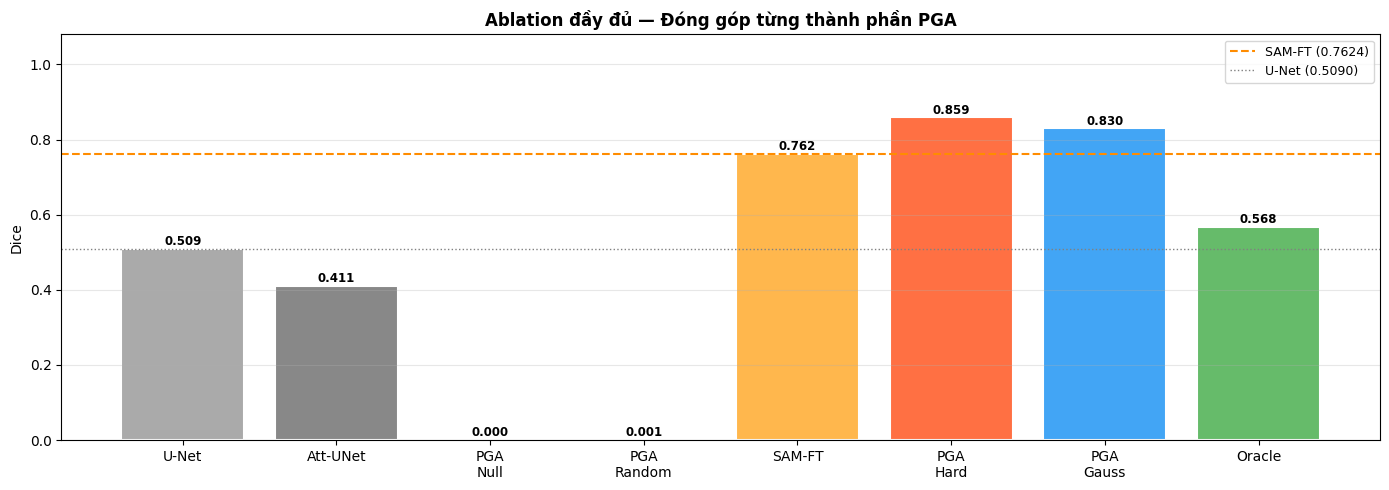

  → CSV: results/ablation/t1b_full_ablation.csv


In [4]:
assert records_gaussian and records_hard,'❌ Chạy T1 trước'
np.random.seed(42)
records_null=[]; records_random=[]; records_oracle=[]
for s in tqdm(TEST_SAMPLES,'T1b'):
    records_null.append(run_forward(s['img_np'],np.zeros((IMG_SIZE,IMG_SIZE),dtype=np.float32),s['gt_np']))
    records_random.append(run_forward(s['img_np'],np.random.rand(IMG_SIZE,IMG_SIZE).astype(np.float32),s['gt_np']))
    records_oracle.append(run_forward(s['img_np'],s['gt_np'],s['gt_np']))

m_null={k:np.mean([r[k] for r in records_null]) for k in KEYS}
m_rnd ={k:np.mean([r[k] for r in records_random]) for k in KEYS}
m_orc ={k:np.mean([r[k] for r in records_oracle]) for k in KEYS}
m_h   ={k:np.mean([r[k] for r in records_hard]) for k in KEYS}
m_g   ={k:np.mean([r[k] for r in records_gaussian]) for k in KEYS}
m_att =dict(dice=0.4110,iou=0.3212,precision=0.6261,recall=0.4035,hd95=141.23,cbl=0.5917)
m_unet=dict(dice=0.5090,iou=0.4125,precision=0.6686,recall=0.5235,hd95=125.12,cbl=0.6457)
m_sam =dict(dice=0.7624,iou=0.6424,precision=0.7597,recall=0.7880,hd95=52.08, cbl=0.9003)
rows=[('\u2460 U-Net (no prompt)*',m_unet),('\u2461 Att-UNet (no prompt)*',m_att),
      ('\u2462 PGA + Null (zeros)',m_null),('\u2463 PGA + Random noise',m_rnd),
      ('\u2464 SAM-Med2D FT (hard bbox)',m_sam),('\u2465 PGA + Hard bbox',m_h),
      ('\u2466 PGA + Gaussian heatmap \u2713',m_g),('\u2467 PGA + Oracle (GT mask)',m_orc)]
print_table('T1b — 5 LOẠI PROMPT  (zoom_out 30%)',rows,len(TEST_SAMPLES))
print('  * N=187 cho U-Net/Att-UNet; N=248 cho PGA/SAM')
bar='─'*60
print(f'\n{bar}\n  PHÂN TÍCH ĐÓNG GÓP\n{bar}')
print(f'  \u0394_arch     = PGA_null − U-Net      : {m_null["dice"]-m_unet["dice"]:+.4f}')
print(f'  \u0394_psg      = PGA_null − PGA_random : {m_null["dice"]-m_rnd["dice"]:+.4f}  (\u22480 → PSG robust)')
print(f'  \u0394_location = PGA_hard − PGA_null  : {m_h["dice"]-m_null["dice"]:+.4f}')
print(f'  \u0394_soft     = PGA_gauss − PGA_hard : {m_g["dice"]-m_h["dice"]:+.4f}')
print(f'  \u0394_arch_sam = PGA_hard − SAM_FT   : {m_h["dice"]-m_sam["dice"]:+.4f}')
print(f'  \u0394_ceiling  = Oracle − Gaussian   : {m_orc["dice"]-m_g["dice"]:+.4f}')
print(bar)
# Bar chart
lbls=['U-Net','Att-UNet','PGA\nNull','PGA\nRandom','SAM-FT','PGA\nHard','PGA\nGauss','Oracle']
dices=[m_unet['dice'],m_att['dice'],m_null['dice'],m_rnd['dice'],m_sam['dice'],m_h['dice'],m_g['dice'],m_orc['dice']]
clrs=['#aaa','#888','#4fc3f7','#b0bec5','#ffb74d','#ff7043','#42a5f5','#66bb6a']
fig,ax=plt.subplots(figsize=(14,5))
bars=ax.bar(lbls,dices,color=clrs,edgecolor='white',linewidth=1.5)
ax.axhline(0.7624,color='darkorange',lw=1.5,ls='--',label='SAM-FT (0.7624)')
ax.axhline(0.5090,color='gray',lw=1,ls=':',label='U-Net (0.5090)')
for b,d in zip(bars,dices): ax.text(b.get_x()+b.get_width()/2,d+0.01,f'{d:.3f}',ha='center',fontsize=8.5,fontweight='bold')
ax.set_ylim(0,1.08); ax.set_ylabel('Dice'); ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)
ax.set_title('Ablation đầy đủ — Đóng góp từng thành phần PGA',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.savefig('results/ablation/t1b_bar.png',dpi=130,bbox_inches='tight'); plt.show()
save_csv('results/ablation/t1b_full_ablation.csv',
    [['U-Net']+[f'{m_unet[k]:.4f}' for k in KEYS]+['187'],
     ['Att-UNet']+[f'{m_att[k]:.4f}' for k in KEYS]+['187'],
     ['PGA Null']+[f'{m_null[k]:.4f}' for k in KEYS]+[str(len(TEST_SAMPLES))],
     ['PGA Random']+[f'{m_rnd[k]:.4f}' for k in KEYS]+[str(len(TEST_SAMPLES))],
     ['SAM-FT']+[f'{m_sam[k]:.4f}' for k in KEYS]+['248'],
     ['PGA Hard']+[f'{m_h[k]:.4f}' for k in KEYS]+[str(len(TEST_SAMPLES))],
     ['PGA Gaussian']+[f'{m_g[k]:.4f}' for k in KEYS]+[str(len(TEST_SAMPLES))],
     ['PGA Oracle']+[f'{m_orc[k]:.4f}' for k in KEYS]+[str(len(TEST_SAMPLES))]],
    ['model']+KEYS+['N'])

---
## T1c — Prompt Robustness
**→ `tab:ablation_robustness`**

PGA nhạy cảm với chất lượng bbox bác sĩ vẽ như thế nào?

| Kịch bản | Mô tả |
|---|---|
| Tight | Bbox chính xác | Zoom 30% ✓ | Kịch bản chính |
| Zoom 60% | Rộng hơn nhiều | Shift 30% | Lệch nhẹ | Shift 50% | Lệch nặng |

  [tight     ] Dice=0.6368  HD95=23.5
  [zoom30    ] Dice=0.8309  HD95=14.2
  [zoom60    ] Dice=0.8275  HD95=15.9
  [shift30   ] Dice=0.6984  HD95=25.9
  [shift50   ] Dice=0.4826  HD95=46.6

══════════════════════════════════════════════════════════════════════════════
  T1c — PROMPT ROBUSTNESS  (Gaussian heatmap)  |  N=248
══════════════════════════════════════════════════════════════════════════════
  Model                                Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑
  ──────────────────────────────────────────────────────────────────────────
  Tight                               0.6368  0.4797  0.9787  0.4858   23.52  0.9476
  Zoom 30% ✓                          0.8309  0.7198  0.9154  0.7785   14.20  0.9526
  Zoom 60%                            0.8275  0.7170  0.8168  0.8667   15.87  0.9410
  Shift 30%                           0.6984  0.5525  0.8494  0.6181   25.87  0.8773
  Shift 50%                           0.4826  0.3397  0.7054  0.3996   46.57  0.7634
════════

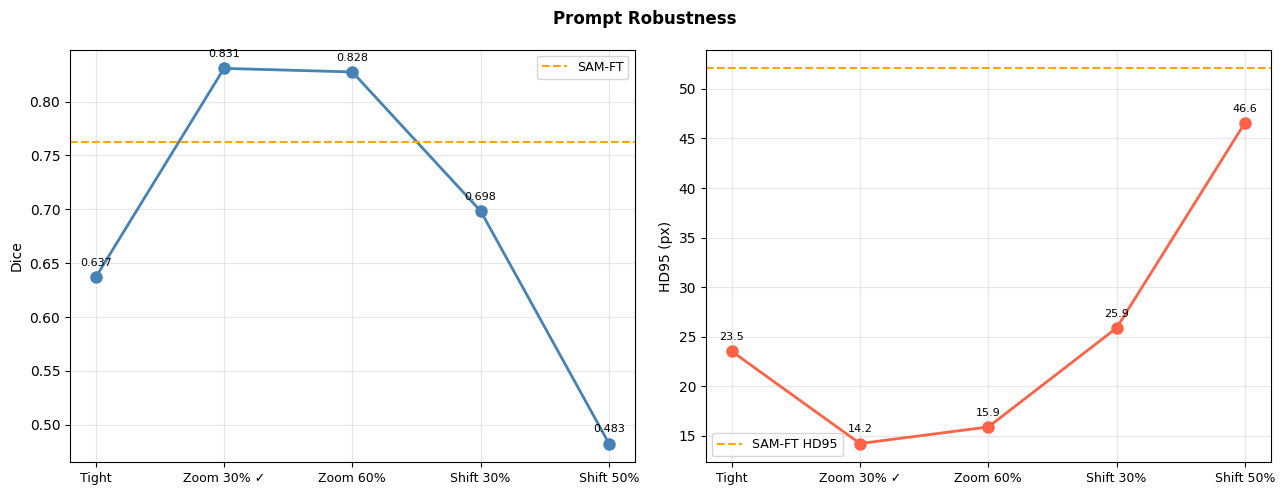

  → CSV: results/ablation/t1c_robustness.csv


In [5]:
def make_variant_prompt(s, mode, size=512):
    ys,xs=np.where(s['gt_np']>0.5)
    if not len(xs): return np.zeros((size,size),dtype=np.float32)
    x1t,x2t,y1t,y2t=float(xs.min()),float(xs.max()),float(ys.min()),float(ys.max())
    bw,bh=x2t-x1t,y2t-y1t
    if mode=='tight': bx1,bx2,by1,by2=x1t,x2t,y1t,y2t
    elif mode=='zoom30': r=.30; bx1=max(0,x1t-bw*r);bx2=min(size,x2t+bw*r);by1=max(0,y1t-bh*r);by2=min(size,y2t+bh*r)
    elif mode=='zoom60': r=.60; bx1=max(0,x1t-bw*r);bx2=min(size,x2t+bw*r);by1=max(0,y1t-bh*r);by2=min(size,y2t+bh*r)
    elif mode=='shift30':
        r=.30; bx1=max(0,x1t-bw*r);bx2=min(size,x2t+bw*r);by1=max(0,y1t-bh*r);by2=min(size,y2t+bh*r)
        dx=bw*.30;dy=bh*.15; bx1=max(0,bx1+dx);bx2=min(size,bx2+dx);by1=max(0,by1+dy);by2=min(size,by2+dy)
    elif mode=='shift50':
        r=.30; bx1=max(0,x1t-bw*r);bx2=min(size,x2t+bw*r);by1=max(0,y1t-bh*r);by2=min(size,y2t+bh*r)
        dx=bw*.50;dy=bh*.25; bx1=max(0,bx1+dx);bx2=min(size,bx2+dx);by1=max(0,by1+dy);by2=min(size,by2+dy)
    else: bx1,bx2,by1,by2=x1t,x2t,y1t,y2t
    return make_gaussian_heatmap([bx1,by1,bx2,by2],size)

VARIANTS=[('Tight','tight'),('Zoom 30% ✓','zoom30'),('Zoom 60%','zoom60'),('Shift 30%','shift30'),('Shift 50%','shift50')]
var_records={}
for lbl,mode in VARIANTS:
    recs=[]
    for s in TEST_SAMPLES:
        recs.append(run_forward(s['img_np'],make_variant_prompt(s,mode),s['gt_np']))
    var_records[lbl]=recs
    print(f'  [{mode:10s}] Dice={np.mean([r["dice"] for r in recs]):.4f}  HD95={np.mean([r["hd95"] for r in recs]):.1f}')

rows_r=[(lbl,{k:np.mean([r[k] for r in recs]) for k in KEYS}) for lbl,recs in var_records.items()]
print_table('T1c — PROMPT ROBUSTNESS  (Gaussian heatmap)',rows_r,len(TEST_SAMPLES))
m_z30={k:np.mean([r[k] for r in var_records['Zoom 30% ✓']]) for k in KEYS}
print('\n  Degradation so với Zoom 30% (chuẩn):')
for lbl,recs in var_records.items():
    m={k:np.mean([r[k] for r in recs]) for k in KEYS}
    print(f'  {lbl:<14}: \u0394 Dice={m["dice"]-m_z30["dice"]:+.4f}  \u0394 HD95={m["hd95"]-m_z30["hd95"]:+.1f} px')

# Plot
dice_m=[np.mean([r['dice'] for r in var_records[l]]) for l,_ in VARIANTS]
hd95_m=[np.mean([r['hd95'] for r in var_records[l]]) for l,_ in VARIANTS]
x_pos=range(len(VARIANTS)); x_lbl=[l for l,_ in VARIANTS]
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,vals,ylabel,color,ref,reflbl in [(axes[0],dice_m,'Dice','steelblue',0.7624,'SAM-FT'),(axes[1],hd95_m,'HD95 (px)','tomato',52.08,'SAM-FT HD95')]:
    ax.plot(x_pos,vals,'o-',color=color,lw=2,ms=8)
    ax.axhline(ref,color='orange',lw=1.5,ls='--',label=reflbl)
    for x,y in zip(x_pos,vals): ax.annotate(f'{y:.3f}' if 'Dice'==ylabel else f'{y:.1f}',(x,y),textcoords='offset points',xytext=(0,8),ha='center',fontsize=8)
    ax.set_xticks(x_pos);ax.set_xticklabels(x_lbl,fontsize=9);ax.set_ylabel(ylabel);ax.legend(fontsize=9);ax.grid(alpha=0.3)
plt.suptitle('Prompt Robustness',fontsize=12,fontweight='bold');plt.tight_layout()
plt.savefig('results/ablation/t1c_robustness.png',dpi=130,bbox_inches='tight');plt.show()
save_csv('results/ablation/t1c_robustness.csv',
    [[l,len(TEST_SAMPLES)]+[f'{np.mean([r[k] for r in var_records[l]]):.4f}' for k in KEYS] for l,_ in VARIANTS],
    ['variant','N']+KEYS)

---
## T2 — Sub-category: Small / Medium / Large
**→ `tab:subcategory`**

Phân nhóm theo diện tích GT mask (px trong 512×512).  Dùng Gaussian heatmap zoom_out 30%.


══════════════════════════════════════════════════════════════════════════
  T2 — SUB-CATEGORY  (Gaussian, zoom_out 30%)
══════════════════════════════════════════════════════════════════════════
  Nhóm                      N     Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑
  ──────────────────────────────────────────────────────────────────────
  Small (<500px)           49    0.8002  0.6707  0.9080  0.7266    3.20  0.9436
  Medium (500-5k)         103    0.8340  0.7248  0.9074  0.7919   10.06  0.9562
  Large (>5k)              96    0.8404  0.7359  0.9297  0.7849   24.38  0.9528
  ──────────────────────────────────────────────────────────────────────
  Overall                 248    0.8298  0.7184  0.9162  0.7763   14.25  0.9524
══════════════════════════════════════════════════════════════════════════
  → CSV: results/ablation/t2_subcategory.csv


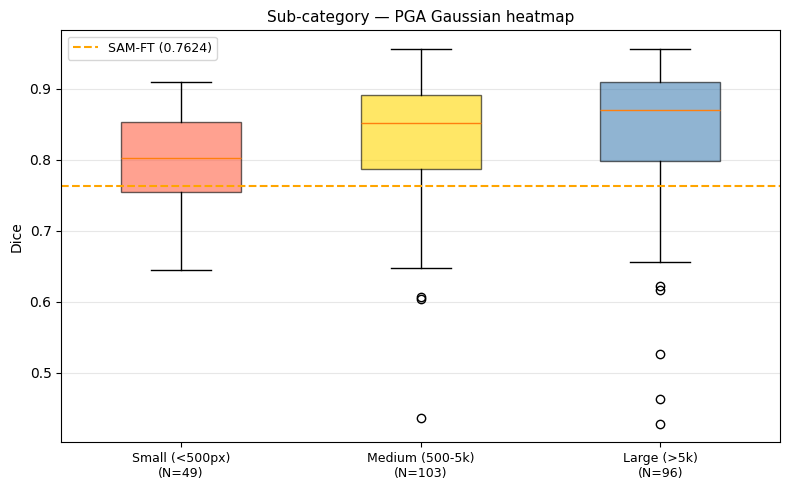

✅ Boxplot saved


In [6]:
assert records_gaussian,'❌ Chạy T1 trước'
BINS=[('Small (<500px)',0,500),('Medium (500-5k)',500,5000),('Large (>5k)',5000,9999999)]
bin_recs={b[0]:[] for b in BINS}
for s,r in zip(TEST_SAMPLES,records_gaussian):
    for bname,lo,hi in BINS:
        if lo<=s['gt_area']<hi: bin_recs[bname].append(r); break

HDRS=['Dice\u2191','IoU\u2191','Prec\u2191','Rec\u2191','HD95\u2193','CBL\u2191']
bar='\u2550'*74; print(f'\n{bar}\n  T2 — SUB-CATEGORY  (Gaussian, zoom_out 30%)\n{bar}')
print(f"  {'Nhóm':<22} {'N':>4}  "+''.join(f'{h:>8}' for h in HDRS)); print(f"  {'─'*70}")
csv_rows=[]; all_rs=[]
for bname,lo,hi in BINS:
    g=bin_recs[bname]
    if not g: print(f'  {bname:<22} {0:>4}  (không có mẫu)'); continue
    m={k:np.mean([r[k] for r in g]) for k in KEYS}
    print(f"  {bname:<22} {len(g):>4}  "+''.join(f"{m[k]:>8.2f}" if k=='hd95' else f"{m[k]:>8.4f}" for k in KEYS))
    csv_rows.append([bname,len(g)]+[f'{m[k]:.4f}' for k in KEYS]); all_rs.extend(g)
if all_rs:
    print(f"  {'─'*70}")
    m={k:np.mean([r[k] for r in all_rs]) for k in KEYS}
    print(f"  {'Overall':<22} {len(all_rs):>4}  "+''.join(f"{m[k]:>8.2f}" if k=='hd95' else f"{m[k]:>8.4f}" for k in KEYS))
print(bar)
save_csv('results/ablation/t2_subcategory.csv',csv_rows,['category','N']+KEYS)
# Boxplot
fig,ax=plt.subplots(figsize=(8,5))
data_p=[]; lbl_p=[]; clr_p=['tomato','gold','steelblue']
for (bname,lo,hi),c in zip(BINS,clr_p):
    g=bin_recs[bname]
    if not g: continue
    data_p.append([r['dice'] for r in g]); lbl_p.append(f'{bname}\n(N={len(g)})')
bp=ax.boxplot(data_p,patch_artist=True,widths=0.5)
for patch,c in zip(bp['boxes'],clr_p): patch.set_facecolor(c);patch.set_alpha(0.6)
ax.axhline(0.7624,color='orange',lw=1.5,ls='--',label='SAM-FT (0.7624)')
ax.set_xticklabels(lbl_p,fontsize=9);ax.set_ylabel('Dice');ax.legend(fontsize=9);ax.grid(axis='y',alpha=0.3)
ax.set_title('Sub-category — PGA Gaussian heatmap',fontsize=11)
plt.tight_layout();plt.savefig('results/ablation/t2_subcategory.png',dpi=120,bbox_inches='tight');plt.show()
print('\u2705 Boxplot saved')

---
## Tổng Kết

| File CSV | Plot | Mục báo cáo |
|---|---|---|
| `results/ablation/t1_hard_vs_gaussian.csv` | — | `tab:ablation_prompt` |
| `results/ablation/t1b_full_ablation.csv` | `t1b_bar.png` | `tab:ablation_prompt` |
| `results/ablation/t1c_robustness.csv` | `t1c_robustness.png` | `tab:ablation_robustness` |
| `results/ablation/t2_subcategory.csv` | `t2_subcategory.png` | `tab:subcategory` |

**Cách đọc kết quả T1b:**
```
Δ_arch     = PGA_null − U-Net      → architecture thuần đóng góp gì
Δ_location = PGA_hard − PGA_null  → thông tin vị trí quan trọng bao nhiêu
Δ_soft     = PGA_gauss − PGA_hard → Gaussian encoding thêm bao nhiêu
Δ_arch_sam = PGA_hard − SAM_FT   → U-Net vs ViT-B khi cùng hard bbox
```